# Session 4 – PCA (Principal Component Analysis) & Cluster Evaluation

## 1. PCA on the Iris Dataset (4 features → 2 components)
The features are standardised first so that every measurement (cm) contributes equally to the principal components.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iris = load_iris()
X, y = iris.data, iris.target
print("Original shape:", X.shape)
print("Features      :", iris.feature_names)
print("Species       :", list(iris.target_names))

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nShape after PCA:", X_pca.shape)
print("Explained variance ratio:")
for i, r in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {r:.4f}  ({r*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

Original shape: (150, 4)
Features      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species       : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Shape after PCA: (150, 2)
Explained variance ratio:
  PC1: 0.7296  (72.96%)
  PC2: 0.2285  (22.85%)
  Total: 0.9581  (95.81%)


In [2]:
# Which original features drive each component? (loadings)
loadings = pd.DataFrame(pca.components_.T, index=iris.feature_names, columns=["PC1", "PC2"])
loadings.round(3)

,PC1,PC2
sepal length (cm),0.521,0.377
sepal width (cm),-0.269,0.923
petal length (cm),0.580,0.024
petal width (cm),0.565,0.067


**Interpretation:** PC1 captures ~73% of the variance and is driven mainly by petal length, petal width and sepal length (overall flower size);
PC2 adds ~23% and is driven mainly by sepal width. Together, two components retain ~96% of the information in the original 4 features.

## 2. 2D PCA Projection Coloured by Species
Just like Spotify maps songs into a 2D "genre space", each flower is placed using its two principal components.

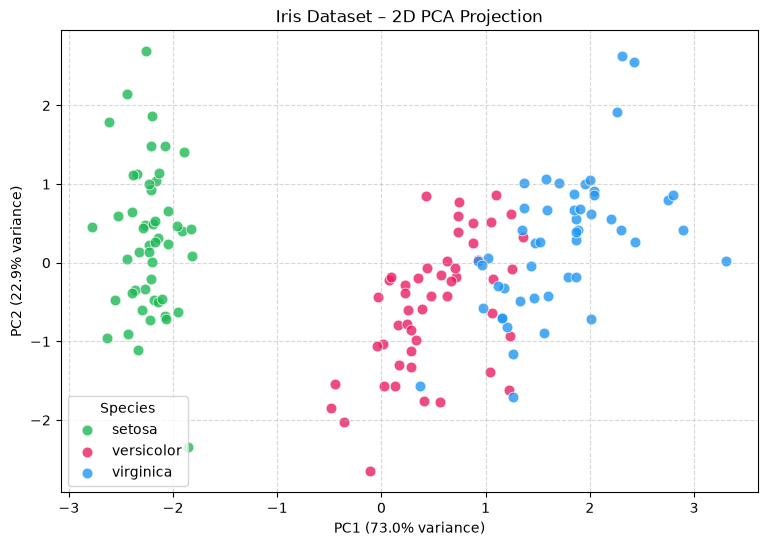

In [3]:
colors = ["#1DB954", "#E91E63", "#2196F3"]   # Spotify-style palette
plt.figure(figsize=(9, 6))
for label, color, name in zip(range(3), colors, iris.target_names):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=60, alpha=0.8,
                edgecolor="white", linewidth=0.6, label=name)

plt.title("Iris Dataset – 2D PCA Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Species")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**Observation:** *Setosa* forms a completely separate group on the left, while *versicolor* and *virginica* sit next to each other with a small overlap –
similar to how distinct genres (e.g. classical) stand apart while related genres (e.g. pop and dance) blend into each other.

## 3. PCA on a Zomato Restaurant Dataset (10 features → 3 components)
We create a realistic dataset of 300 restaurants with 10 correlated features.
The features are driven by three hidden factors – **quality**, **price level** and **popularity** – so PCA should be able to compress them well.

In [4]:
rng = np.random.default_rng(42)
n = 300

# Hidden (latent) factors
quality    = rng.normal(0, 1, n)
price      = rng.normal(0, 1, n)
popularity = rng.normal(0, 1, n)
noise = lambda s: rng.normal(0, s, n)

zomato = pd.DataFrame({
    "overall_rating":     np.clip(3.8 + 0.45 * quality + noise(0.15), 1, 5),
    "food_rating":        np.clip(3.9 + 0.50 * quality + noise(0.20), 1, 5),
    "service_rating":     np.clip(3.7 + 0.40 * quality + 0.15 * price + noise(0.20), 1, 5),
    "ambience_rating":    np.clip(3.6 + 0.20 * quality + 0.45 * price + noise(0.20), 1, 5),
    "price_for_two":      np.clip(800 + 450 * price + noise(80), 150, None),
    "num_votes":          np.clip(1200 + 700 * popularity + 200 * quality + noise(150), 10, None),
    "delivery_time_min":  np.clip(35 - 5 * popularity + 4 * price + noise(4), 10, None),
    "discount_pct":       np.clip(15 - 6 * price + 3 * popularity + noise(3), 0, 60),
    "num_cuisines":       np.clip(np.round(3 + 1.0 * price + noise(0.8)), 1, None),
    "online_order_share": np.clip(0.55 + 0.15 * popularity - 0.08 * price + noise(0.05), 0, 1),
})

print("Shape:", zomato.shape)
zomato.round(2).head()

Shape: (300, 10)


,overall_rating,food_rating,service_rating,ambience_rating,price_for_two,num_votes,delivery_time_min,discount_pct,num_cuisines,online_order_share
0,4.00,3.79,3.97,4.43,1597.84,1554.82,42.76,9.93,5.0,0.54
1,3.35,3.28,2.93,2.79,150.00,734.75,27.30,24.53,3.0,0.71
2,4.12,4.36,4.39,4.08,1131.62,2284.38,35.42,19.54,5.0,0.60
3,4.46,4.35,4.09,3.56,713.91,844.17,41.57,10.44,3.0,0.56
4,2.83,2.79,2.87,3.20,750.03,234.27,38.78,12.66,5.0,0.46


In [5]:
Z_scaled = StandardScaler().fit_transform(zomato)

# Fit PCA with all 10 components to see the full variance picture
pca_full = PCA().fit(Z_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Reduce to 3 components
pca3 = PCA(n_components=3)
Z_pca = pca3.fit_transform(Z_scaled)
print("Reduced shape:", Z_pca.shape)
for i, r in enumerate(pca3.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {r*100:.2f}%")
print(f"Cumulative variance retained by 3 components: {pca3.explained_variance_ratio_.sum()*100:.2f}%")

Reduced shape: (300, 3)
  PC1: 47.40%
  PC2: 26.35%
  PC3: 14.88%
Cumulative variance retained by 3 components: 88.63%


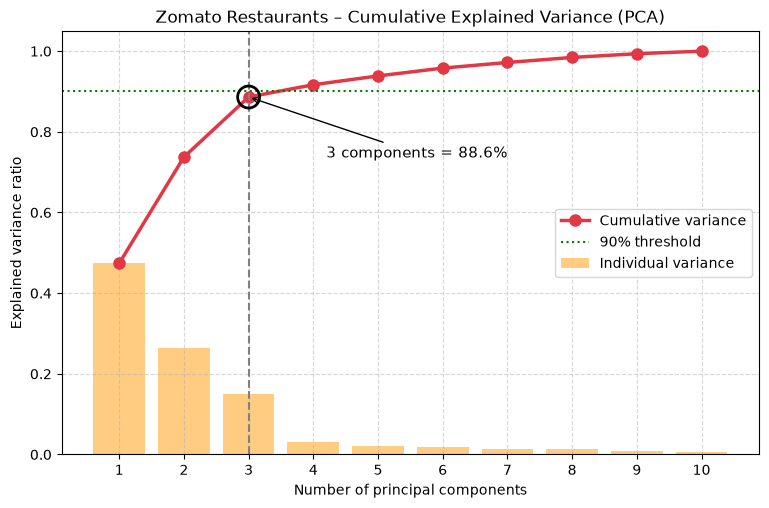

In [6]:
components = np.arange(1, len(cum_var) + 1)

plt.figure(figsize=(9, 5.5))
plt.bar(components, pca_full.explained_variance_ratio_, color="#FFB74D", alpha=0.7, label="Individual variance")
plt.plot(components, cum_var, "o-", color="#E23744", linewidth=2.5, markersize=8, label="Cumulative variance")
plt.axvline(3, color="grey", linestyle="--")
plt.scatter(3, cum_var[2], s=250, facecolors="none", edgecolors="black", linewidths=2, zorder=5)
plt.annotate(f"3 components = {cum_var[2]*100:.1f}%", (3, cum_var[2]),
             xytext=(4.2, cum_var[2] - 0.15), arrowprops=dict(arrowstyle="->"), fontsize=11)
plt.axhline(0.90, color="green", linestyle=":", label="90% threshold")
plt.title("Zomato Restaurants – Cumulative Explained Variance (PCA)")
plt.xlabel("Number of principal components")
plt.ylabel("Explained variance ratio")
plt.xticks(components)
plt.ylim(0, 1.05)
plt.legend(loc="center right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [7]:
# Which features load on each of the 3 components?
zl = pd.DataFrame(pca3.components_.T, index=zomato.columns, columns=["PC1", "PC2", "PC3"])
zl.round(2)

,PC1,PC2,PC3
overall_rating,-0.11,0.54,-0.24
food_rating,-0.13,0.53,-0.23
service_rating,-0.26,0.45,-0.06
ambience_rating,-0.39,0.14,0.28
price_for_two,-0.39,-0.07,0.35
num_votes,0.20,0.34,0.54
delivery_time_min,-0.38,-0.16,-0.25
discount_pct,0.42,0.13,-0.03
num_cuisines,-0.32,-0.06,0.44
online_order_share,0.37,0.19,0.35


**Interpretation:** The first 3 components retain **~88.6%** of the variance of the 10 original features (PC1 ≈ 47%, PC2 ≈ 26%, PC3 ≈ 15%),
and the curve flattens afterwards – components 4–10 mostly capture noise. From the loadings:
- **PC1 – "premium vs. value"**: price, ambience, cuisines and delivery time on one side; discounts and online-order share on the other.
- **PC2 – "quality"**: dominated by overall, food and service ratings.
- **PC3 – "popularity / reach"**: number of votes, online orders, cuisines and price.

So 10 features can be compressed into 3 meaningful dimensions with little information loss.

## 4. K-Means (k=3) on the PCA-Reduced Iris Data

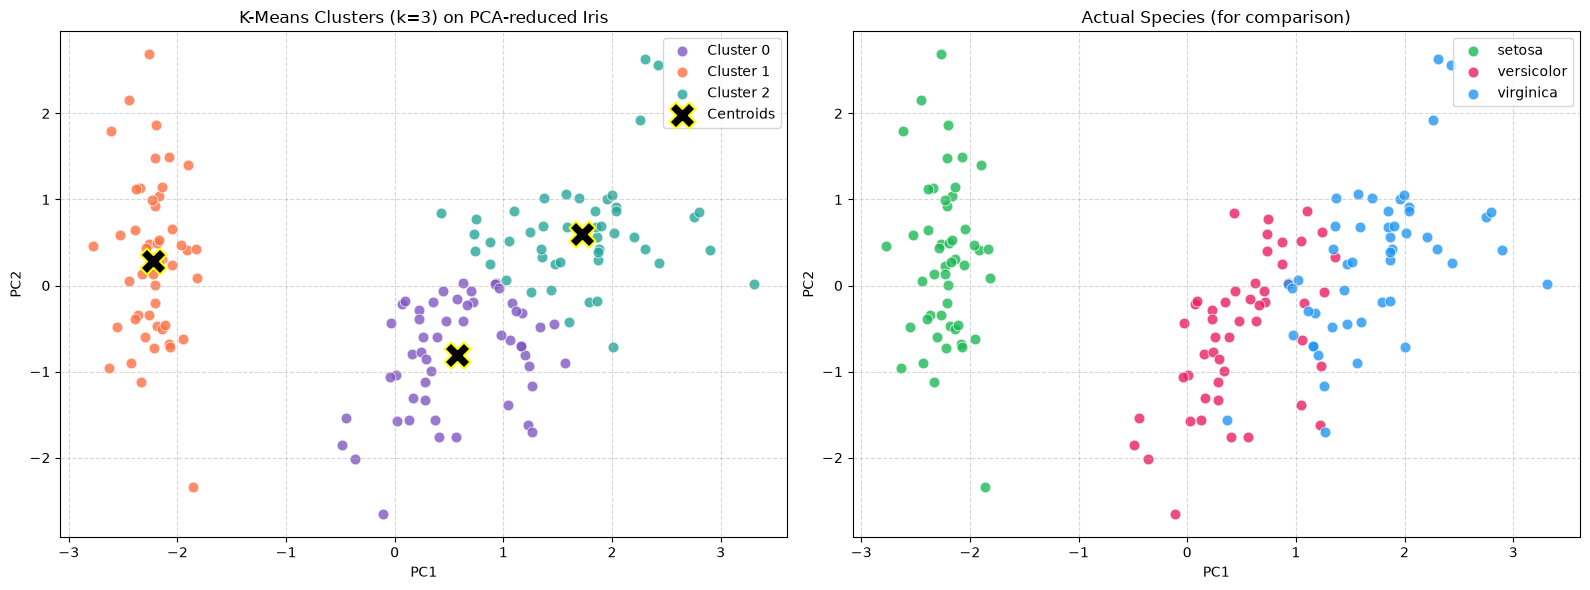

Centroids (PC1, PC2):
     PC1    PC2
0  0.573 -0.807
1 -2.225  0.289
2  1.721  0.603

Cluster vs actual species:
Species  setosa  versicolor  virginica
Cluster                               
0             0          39         14
1            50           0          0
2             0          11         36


In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: K-Means clusters + centroids
cluster_colors = ["#7E57C2", "#FF7043", "#26A69A"]
for c in range(3):
    mask = clusters == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[c], s=60, alpha=0.8,
                    edgecolor="white", linewidth=0.6, label=f"Cluster {c}")
axes[0].scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=350,
                edgecolor="yellow", linewidth=1.5, label="Centroids")
axes[0].set_title("K-Means Clusters (k=3) on PCA-reduced Iris")

# Right: true species for comparison
for label, color, name in zip(range(3), colors, iris.target_names):
    mask = y == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=60, alpha=0.8,
                    edgecolor="white", linewidth=0.6, label=name)
axes[1].set_title("Actual Species (for comparison)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Centroids (PC1, PC2):")
print(pd.DataFrame(centroids, columns=["PC1", "PC2"]).round(3))
print("\nCluster vs actual species:")
print(pd.crosstab(clusters, iris.target_names[y], rownames=["Cluster"], colnames=["Species"]))

## 5. Silhouette Score
The silhouette score ranges from **-1 to +1**:
- close to **+1** → points are well inside their own cluster and far from others
- around **0** → clusters overlap / points lie on boundaries
- **negative** → points are probably in the wrong cluster

In [9]:
score = silhouette_score(X_pca, clusters)
print(f"Silhouette Score (KMeans k=3 on PCA-reduced Iris): {score:.4f}")

# For context: compare with other values of k
print("\nSilhouette score for different k:")
for k in range(2, 7):
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca)
    print(f"  k={k}: {silhouette_score(X_pca, lbl):.4f}")

Silhouette Score (KMeans k=3 on PCA-reduced Iris): 0.5092

Silhouette score for different k:
  k=2: 0.6145
  k=3: 0.5092
  k=4: 0.4409
  k=5: 0.4156
  k=6: 0.4140


### What the score indicates
A silhouette score of about **0.51** means the clusters are **reasonably well-defined** – most flowers are clearly closer to their own cluster than to a neighbouring one.
It is not close to 1 because *versicolor* and *virginica* overlap in the PCA space, so points near their shared boundary pull the average down,
while *setosa* forms a very compact, well-separated cluster. (k=2 scores higher only because it merges the two overlapping species, but k=3 matches the real species better.)